# Pandas, NumPy, and Plotting

In this notebook you will move from small Python lists to real basin data.

By the end of the notebook, you should be able to:

- create and do arithmetic with NumPy arrays
- rewrite a loop over values as one line of `np.where`
- read a CSV file into a pandas DataFrame
- inspect a DataFrame with `.head()`, `.shape`, and `.describe()`
- select one column as a Series
- make a simple line plot with `matplotlib`
- make a multi-panel figure with shared x-axis
- save a figure to disk
- merge two DataFrames on a common column
- use the `.dt` accessor to pull date parts out of a date column
- use `.groupby(...)` to compute monthly means

We will work with daily ERA5-Land precipitation and temperature for the Alamedin basin in Kyrgyzstan.


## How To Use This Notebook

This notebook mixes explanation, code, and short interpretations.

Suggested rhythm:

- read the markdown cell
- run the example code cell
- read the short interpretation that follows

There are no separate exercise cells in this notebook. Instead, the code cells themselves show the full pattern, and the interpretation cells explain what the output means.

Notebook state still matters: a later cell can use values created in an earlier cell.

Type hints appear on all function signatures, as introduced in notebook 04. Read them as helpful labels: `list[float]` means a list of decimal numbers, `float | None` means a decimal number or nothing.


## 1. Setup: Imports, Data Paths, And Helper Functions

Before we load any data, we import the libraries we will use and define where the data lives.

- `pandas` gives us DataFrames, which are tables with named columns
- `numpy` gives us arrays, which are fast numeric containers
- `matplotlib.pyplot` gives us plotting functions
- `pathlib.Path` gives us a clean way to build file paths that works on every operating system

We also define `DATA_ROOT` once so the rest of the notebook does not need to repeat the full path.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA_ROOT = Path.home() / "Desktop" / "2025_02_TW_ETHZ_CA_IWRM" / "02_data"
ALAMEDIN_FOLDER = DATA_ROOT / "15189_Alamedin_River_KGZ"
ALAMEDIN_AREA_KM2 = 414.05
ALAMEDIN_GAUGE_LAT_DEG = 42.697

print(DATA_ROOT)
print(ALAMEDIN_FOLDER.exists())


/Users/nicolaslazaro/Desktop/2025_02_TW_ETHZ_CA_IWRM/02_data
True


`DATA_ROOT` now points to the shared data folder, and `ALAMEDIN_FOLDER.exists()` returns `True`, which confirms the path is correct.

`ALAMEDIN_AREA_KM2` and `ALAMEDIN_GAUGE_LAT_DEG` are catchment descriptors we will reuse several times. Storing them as named constants near the top keeps later code readable.


### Helper Functions

Below we have implemented some functions to help you in the analysis and preprocessing of the data. Take your time and try to understand the code. We do not expect you to be able to reproduce these.

The two functions are:

- `compute_gap_lengths(series)` — for every missing day in a streamflow series, report how long the surrounding missing run is. We will use this later when we look at streamflow gaps.
- `extraterrestrial_radiation(doy, lat_rad)` — daily top-of-atmosphere solar radiation as a function of day of year and latitude. We will use this later to estimate potential evapotranspiration.

Both functions use NumPy arrays and pandas Series. You will see arrays introduced in the next section.


In [2]:
def compute_gap_lengths(series: pd.Series) -> pd.Series:
    """For each missing entry, return the length of its contiguous missing run.

    Observed entries get 0. A single isolated NaN gets 1. A 14-day missing run
    gets 14 on every one of those 14 rows.
    """
    missing_mask = series.isna()
    group_id = missing_mask.ne(missing_mask.shift(fill_value=False)).cumsum()

    gap_length = pd.Series(0, index=series.index, dtype="int64")
    gap_length.loc[missing_mask] = missing_mask.groupby(group_id).transform("sum").loc[missing_mask].astype("int64")
    return gap_length


def extraterrestrial_radiation(doy: np.ndarray, lat_rad: float) -> np.ndarray:
    """Daily extraterrestrial radiation R_a [MJ m-2 day-1] (FAO-56)."""
    solar_constant = 0.0820  # MJ m-2 min-1
    dr = 1.0 + 0.033 * np.cos(2.0 * np.pi / 365.0 * doy)
    delta = 0.4093 * np.sin(2.0 * np.pi / 365.0 * doy - 1.405)
    omega_s = np.arccos(-np.tan(lat_rad) * np.tan(delta))
    return (
        (24.0 * 60.0 / np.pi)
        * solar_constant
        * dr
        * (omega_s * np.sin(lat_rad) * np.sin(delta) + np.cos(lat_rad) * np.cos(delta) * np.sin(omega_s))
    )

Running the cell just defined the two functions. It did not produce any scientific output yet. We will call these helpers later, in the second half of the notebook.


## 2. NumPy Arrays And `np.where`

In notebook 01 we stored a short rainfall series in a Python list. Lists are fine for a few values, but not for 40 years of daily data.

A **NumPy array** is a container for numbers that supports fast elementwise arithmetic. That means operations like "add 5 to every value" or "multiply every value by 10" take one line, not a loop.

You can create an array from a Python list with `np.array(...)`.


In [3]:
rainfall_mm = np.array([12.0, 4.5, 0.0, 7.2, 3.1])
temperature_c = np.array([-2.0, 0.5, 3.0, -1.5, 4.0])

print(rainfall_mm)
print(rainfall_mm * 2.0)
print(rainfall_mm + 1.0)
print(rainfall_mm.shape)
print(rainfall_mm.mean())


[12.   4.5  0.   7.2  3.1]
[24.   9.   0.  14.4  6.2]
[13.   5.5  1.   8.2  4.1]
(5,)
5.36


Two things to notice:

- `rainfall_mm * 2.0` multiplies every value in the array by `2.0` in one step. There is no `for` loop.
- `rainfall_mm.shape` reports `(5,)`, which means one dimension of length 5. This `shape` attribute becomes very useful once we work with longer arrays.

`rainfall_mm.mean()` returns the average of all values.


### Classifying Precipitation As Snow Or Rain

In notebook 02 you used `if` and `else` to classify a single day as snow or rain based on temperature. In notebook 03 you put that same logic inside a `for` loop to label a whole list.

Let's do that again here with arrays, first with the loop you already know, then with one line of NumPy.

The rule is the same as in notebook 02: temperature at or below `0.0` means snow, otherwise rain.


In [4]:
precipitation_type_loop = []

for temperature_value_c in temperature_c:
    if (temperature_value_c <= 0.0):
        precipitation_type_loop.append("snow")
    else:
        precipitation_type_loop.append("rain")

print(precipitation_type_loop)


['snow', 'rain', 'rain', 'snow', 'rain']


That works, and it is exactly the pattern from notebook 03.

NumPy gives us a shorter way to write the same thing: `np.where(condition, value_if_true, value_if_false)`.

It walks through the array once and picks one of the two values on each row, based on the condition.


In [5]:
precipitation_type_np = np.where(temperature_c <= 0.0, "snow", "rain")

print(precipitation_type_np)


['snow' 'rain' 'rain' 'snow' 'rain']


The result is the same list of labels. The only surface difference is that NumPy prints its arrays without commas.

The deeper point: `np.where` does not introduce a new idea. It is the same "check a condition, pick one of two outcomes" pattern from notebook 02, applied to a whole array at once.

You will see `np.where` again when we partition precipitation into solid and liquid parts in the second half of the notebook.


## 3. Loading A CSV Into A DataFrame

Our Alamedin precipitation data lives in a CSV file on disk. We need two things that a plain NumPy array does not give us:

- a label for each row (the date)
- a label for each column (what the variable is)

A **pandas DataFrame** is a table that has both. A useful one-line summary:

> A DataFrame is a dict of Series. A Series is a NumPy array with a row label.

We read a CSV with `pd.read_csv(...)`. The `parse_dates=["date"]` argument tells pandas that the `date` column contains dates, not plain text.


In [6]:
precipitation_path = ALAMEDIN_FOLDER / "02_forcing" / "era5_precipitation_daily.csv"

precipitation_df = pd.read_csv(precipitation_path, parse_dates=["date"])

print(precipitation_df.head())
print()
print("shape:", precipitation_df.shape)
print()
print(precipitation_df.describe())


        date  precipitation_mm
0 1981-01-01            0.3963
1 1981-01-02            0.2877
2 1981-01-03            0.2567
3 1981-01-04            0.8757
4 1981-01-05            1.2102

shape: (16071, 2)

                      date  precipitation_mm
count                16071      16071.000000
mean   2003-01-01 00:00:00          3.718406
min    1981-01-01 00:00:00          0.000000
25%    1992-01-01 12:00:00          0.102200
50%    2003-01-01 00:00:00          1.453500
75%    2013-12-31 12:00:00          5.641750
max    2024-12-31 00:00:00         52.907200
std                    NaN          5.072285


Each of those three lines is a tool you will reuse constantly:

- `.head()` returns the first five rows. Use it to confirm the columns look right and the dates start where you expected.
- `.shape` returns `(n_rows, n_columns)`. Alamedin's ERA5 record has `16071` daily rows and `2` columns.
- `.describe()` returns summary statistics for every numeric column. Scan it for obviously broken numbers: negative precipitation, a maximum of 99999, that kind of thing.

From `describe()` we can already see that daily precipitation at Alamedin averages about 3.7 mm, the smallest value is `0.0` (dry days), and the largest is around 53 mm (a very wet day).


### Selecting One Column

We can pull out a single column by name using square brackets. The result is a pandas **Series**: one column of data, with the same date-based row labels as the DataFrame.


In [7]:
precipitation_series_mm = precipitation_df["precipitation_mm"]

print(type(precipitation_series_mm))
print(precipitation_series_mm.head())
print()
print("max:", precipitation_series_mm.max())
print("mean:", precipitation_series_mm.mean())
print("underlying numpy array:", precipitation_series_mm.values[:5])


<class 'pandas.Series'>
0    0.3963
1    0.2877
2    0.2567
3    0.8757
4    1.2102
Name: precipitation_mm, dtype: float64

max: 52.9072
mean: 3.7184060232717315
underlying numpy array: [0.3963 0.2877 0.2567 0.8757 1.2102]


A Series behaves like a NumPy array for arithmetic (`.mean()`, `.max()`, `series * 2.0` all work), but it also carries its row labels. When we access `.values`, we get the plain NumPy array underneath.

That is the link between sections 2 and 3: everything you learned about array arithmetic still applies, once you pick out a column.


## 4. Plotting With Matplotlib

Looking at numbers in a DataFrame tells us very little about 40 years of precipitation. A plot tells us a lot.

The standard matplotlib pattern has two steps:

1. create a **figure** and one or more **axes** with `plt.subplots(...)`
2. call plotting methods on the axes (`ax.plot(...)`, `ax.set_xlabel(...)`, and so on)

A `figure` is the whole window. An `axes` is one panel inside the figure. Most figures in this notebook have one or two panels.


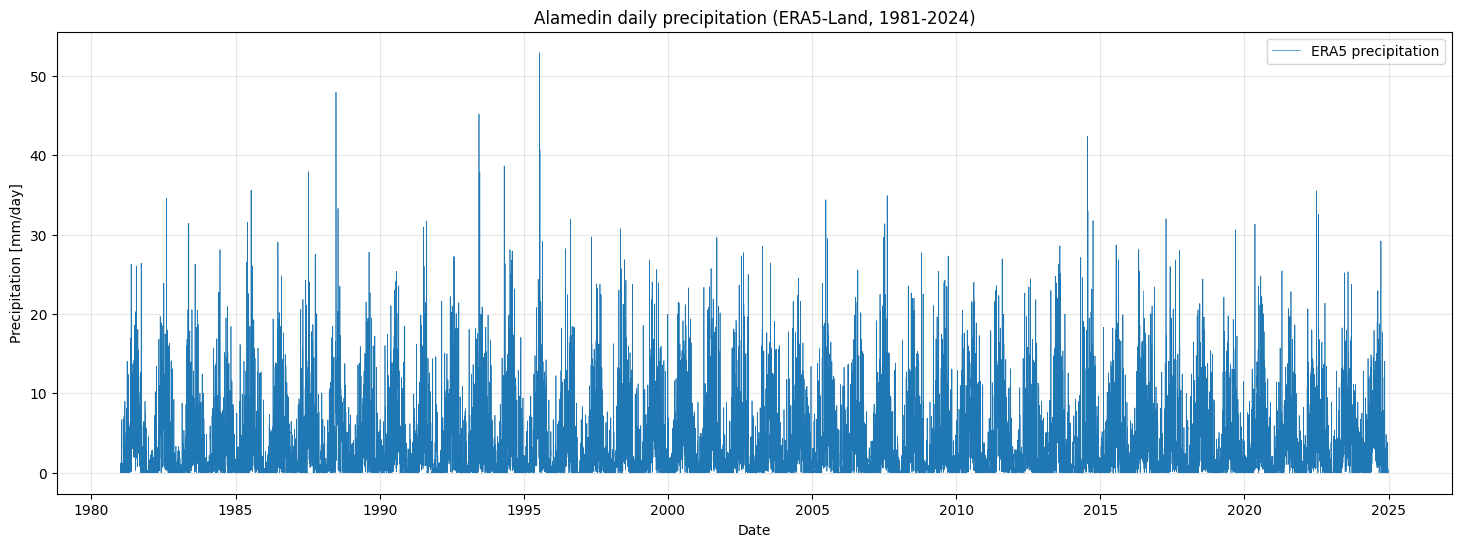

In [8]:
fig, ax = plt.subplots(figsize=(18, 6))

ax.plot(
    precipitation_df["date"],
    precipitation_df["precipitation_mm"],
    color="tab:blue",
    linewidth=0.5,
    label="ERA5 precipitation",
)

ax.set_xlabel("Date")
ax.set_ylabel("Precipitation [mm/day]")
ax.set_title("Alamedin daily precipitation (ERA5-Land, 1981-2024)")
ax.legend()
ax.grid(alpha=0.3)

plt.show()


The plot shows the full 44-year precipitation record for Alamedin.

Two immediate observations:

- there is no obvious trend or jump in the data (good — that means the forcing record is homogeneous)
- daily precipitation is very seasonal, with a wet days each year pushing above 30 mm

For a dataset this long, a raw daily line plot is the right first look. Later we will aggregate to monthly means, which is much easier to read.


### A Two-Panel Figure: Precipitation And Temperature

Precipitation is only half of the meteorological forcing. We also need temperature, which lives in a separate CSV file in the same folder. Let's load it and make a two-panel figure with a shared date axis.

Two panels that share the x-axis are useful when you want to compare variables over the same period.


In [9]:
temperature_path = ALAMEDIN_FOLDER / "02_forcing" / "era5_temperature_daily.csv"
temperature_df = pd.read_csv(temperature_path, parse_dates=["date"])

print(temperature_df.head())
print("shape:", temperature_df.shape)

        date  temperature_degC
0 1981-01-01           -8.3541
1 1981-01-02           -8.6758
2 1981-01-03           -8.9181
3 1981-01-04          -10.1155
4 1981-01-05          -11.4220
shape: (16071, 2)


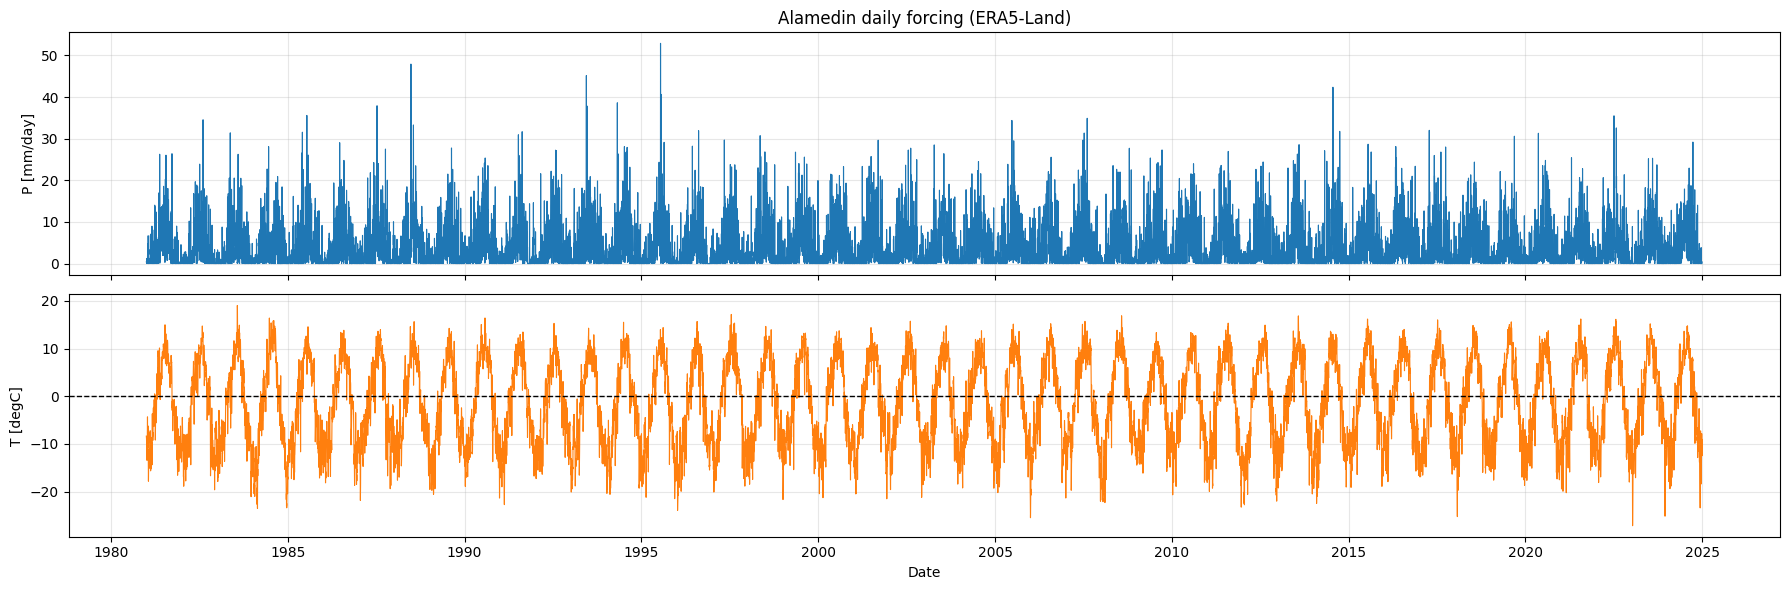

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(18, 6), sharex=True)

axes[0].plot(precipitation_df["date"], precipitation_df["precipitation_mm"], color="tab:blue", linewidth=0.8)
axes[0].set_ylabel("P [mm/day]")
axes[0].set_title("Alamedin daily forcing (ERA5-Land)")
axes[0].grid(alpha=0.3)

axes[1].plot(temperature_df["date"], temperature_df["temperature_degC"], color="tab:orange", linewidth=0.8)
axes[1].axhline(0.0, color="black", linewidth=1.0, linestyle="--")
axes[1].set_ylabel("T [degC]")
axes[1].set_xlabel("Date")
axes[1].grid(alpha=0.3)

fig.tight_layout()
plt.show()

Two things jump out now that the panels are aligned:

- temperature has a clear annual cycle: summer highs near 20°C, winter lows near -25°C
- the dashed line at 0°C is where rain turns to snow in our simple threshold rule from section 2. A large fraction of the year lies below that line

### Saving A Figure To Disk

`plt.show()` displays a figure in the notebook, but it does not save it. For a report, a presentation, or a supervisor email, you want a copy on disk.

Use `fig.savefig(path, dpi=..., bbox_inches="tight")`. `dpi=150` is a good default for screen reports; `dpi=300` for print.

Saving matters for reproducibility: a figure file is a permanent record of what the data looked like at the time of analysis. If the data gets cleaned or filtered later, the saved figure lets you compare before and after.


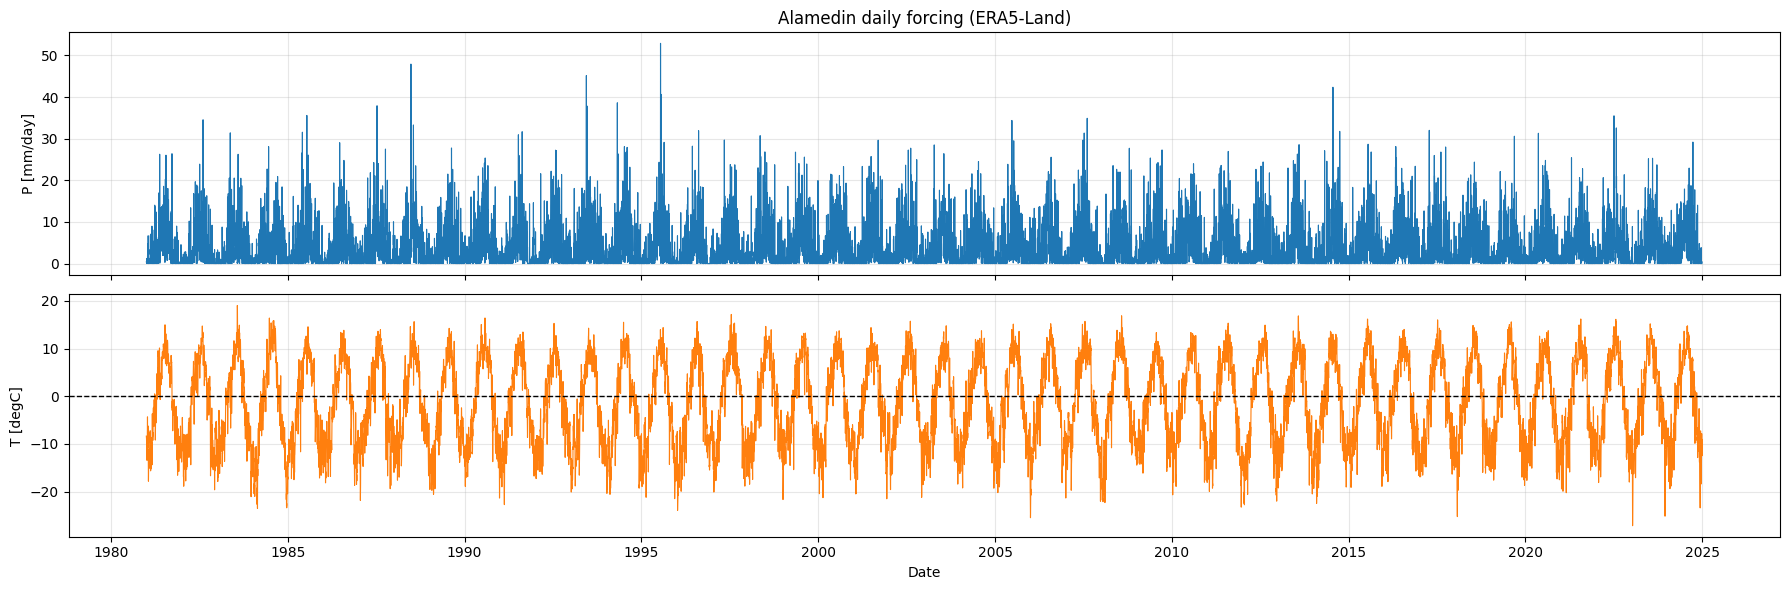

Saved figure to: /Users/nicolaslazaro/Desktop/work/wat-mod-GIZ/notebooks/figures/alamedin_daily_forcing.png


In [11]:
figures_dir = Path("figures")
figures_dir.mkdir(exist_ok=True) # This will create a directory named "figures" in the current working directory if it doesn't already exist.

fig, axes = plt.subplots(2, 1, figsize=(18, 6), sharex=True)

axes[0].plot(precipitation_df["date"], precipitation_df["precipitation_mm"], color="tab:blue", linewidth=0.8)
axes[0].set_ylabel("P [mm/day]")
axes[0].set_title("Alamedin daily forcing (ERA5-Land)")
axes[0].grid(alpha=0.3)

axes[1].plot(temperature_df["date"], temperature_df["temperature_degC"], color="tab:orange", linewidth=0.8)
axes[1].axhline(0.0, color="black", linewidth=1.0, linestyle="--")
axes[1].set_ylabel("T [degC]")
axes[1].set_xlabel("Date")
axes[1].grid(alpha=0.3)

fig.tight_layout()

output_path = figures_dir / "alamedin_daily_forcing.png"
fig.savefig(output_path, dpi=150, bbox_inches="tight")

plt.show()

print(f"Saved figure to: {output_path.resolve()}")


## 5. Combining DataFrames With `merge`

Right now precipitation and temperature live in two separate DataFrames. If we want to compute something that uses both variables on the same day — for example, the solid-snow fraction — we need them in one table.

`pd.merge(left, right, on="date")` joins two DataFrames row-by-row on a shared column. Every row in the result has the date, the precipitation from `left`, and the temperature from `right`.

Merging is strict about two things:

- the column you merge **on** must exist in both DataFrames and be named identically
- the values in that column should have the same type. Here both `date` columns are pandas datetimes, because we passed `parse_dates=["date"]` when we loaded the CSVs.


In [12]:
forcing_df = pd.merge(precipitation_df, temperature_df, on="date")

print(forcing_df.head())
print()
print("shape:", forcing_df.shape)
print("columns:", list(forcing_df.columns))


        date  precipitation_mm  temperature_degC
0 1981-01-01            0.3963           -8.3541
1 1981-01-02            0.2877           -8.6758
2 1981-01-03            0.2567           -8.9181
3 1981-01-04            0.8757          -10.1155
4 1981-01-05            1.2102          -11.4220

shape: (16071, 3)
columns: ['date', 'precipitation_mm', 'temperature_degC']


The merged DataFrame has `16071` rows (same as each input) and `3` columns. Each row now carries both the precipitation value and the temperature value for that day.

If one of the two CSVs had had an extra date that the other did not, the default `how="inner"` would have dropped that date. That is the behavior we want here — we only care about days where both variables exist.

From this section onward, `forcing_df` is the single source of truth for Alamedin meteorology in this notebook.


Now that both variables are in one DataFrame, the two-panel plot from section 4 becomes simpler: one source, not two.


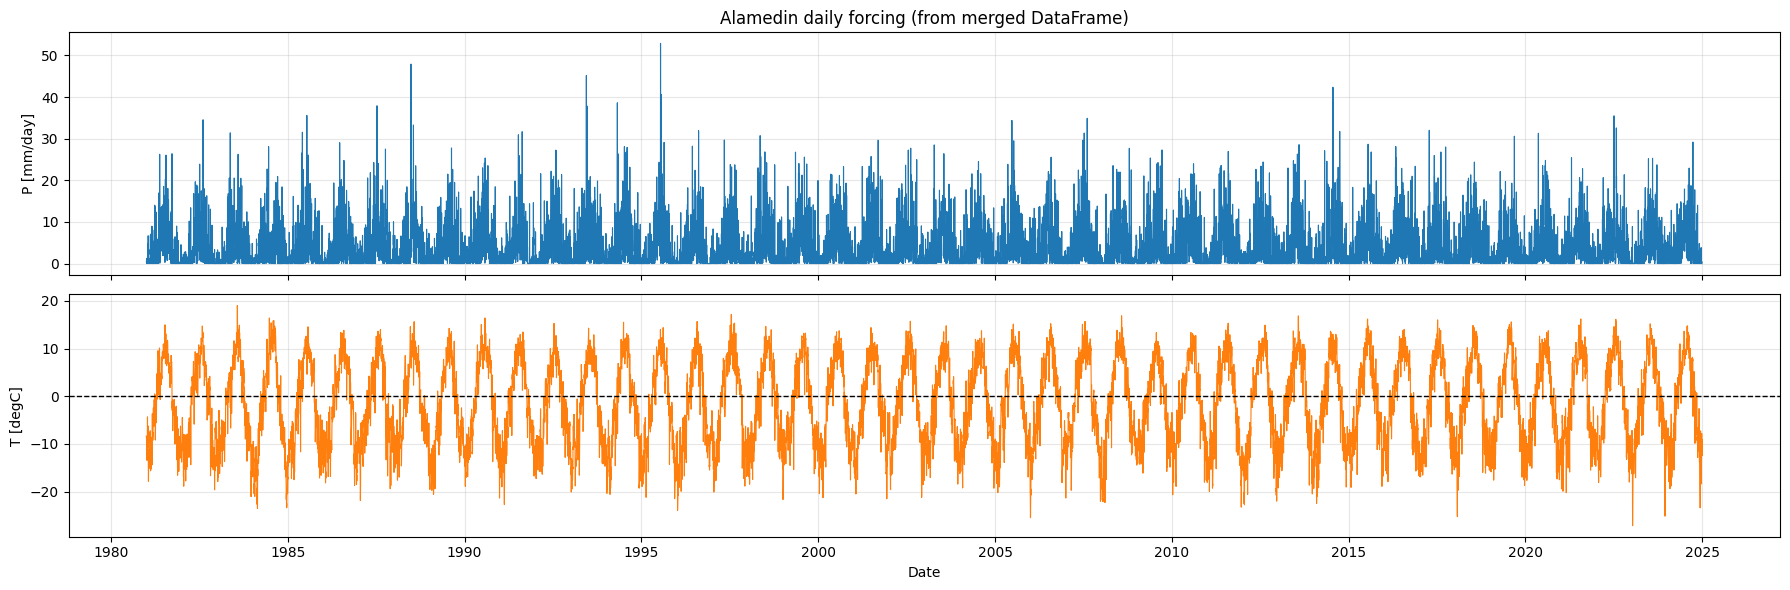

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(18, 6), sharex=True)

axes[0].plot(forcing_df["date"], forcing_df["precipitation_mm"], color="tab:blue", linewidth=0.8)
axes[0].set_ylabel("P [mm/day]")
axes[0].set_title("Alamedin daily forcing (from merged DataFrame)")
axes[0].grid(alpha=0.3)

axes[1].plot(forcing_df["date"], forcing_df["temperature_degC"], color="tab:orange", linewidth=0.8)
axes[1].axhline(0.0, color="black", linewidth=1.0, linestyle="--")
axes[1].set_ylabel("T [degC]")
axes[1].set_xlabel("Date")
axes[1].grid(alpha=0.3)

fig.tight_layout()
plt.show()


Identical figure, but the code is cleaner: one DataFrame instead of two. That matters more once we have five or six variables instead of two.


## 6. The `.dt` Accessor And Monthly Climatology

So far we have treated the `date` column as just a label. In pandas, a datetime column carries a lot of extra information. The `.dt` accessor pulls it out.

Three that we will use:

- `forcing_df["date"].dt.year` — the year of each row (e.g., `1981`)
- `forcing_df["date"].dt.month` — the month, 1 through 12
- `forcing_df["date"].dt.dayofyear` — the day of the year, 1 through 365 or 366

Day of year is especially useful for hydrology because it aligns the same calendar day across every year. You may remember seeing it in the helper `extraterrestrial_radiation(doy, lat_rad)` from the toolbox cell.


In [14]:
forcing_df["year"] = forcing_df["date"].dt.year
forcing_df["month"] = forcing_df["date"].dt.month
forcing_df["day_of_year"] = forcing_df["date"].dt.dayofyear

print(forcing_df.head())
print()
print(forcing_df[["year", "month", "day_of_year"]].describe())


        date  precipitation_mm  temperature_degC  year  month  day_of_year
0 1981-01-01            0.3963           -8.3541  1981      1            1
1 1981-01-02            0.2877           -8.6758  1981      1            2
2 1981-01-03            0.2567           -8.9181  1981      1            3
3 1981-01-04            0.8757          -10.1155  1981      1            4
4 1981-01-05            1.2102          -11.4220  1981      1            5

               year        month   day_of_year
count  16071.000000  16071.00000  16071.000000
mean    2002.501027      6.52293    183.125257
std       12.698847      3.44881    105.441923
min     1981.000000      1.00000      1.000000
25%     1992.000000      4.00000     92.000000
50%     2003.000000      7.00000    183.000000
75%     2013.500000     10.00000    274.000000
max     2024.000000     12.00000    366.000000


### Averaging By Month With `groupby`

To see the annual cycle, we want the average precipitation and temperature for each calendar month, taken across all years.

`forcing_df.groupby("month")["precipitation_mm"].mean()` does exactly that:

1. split the rows into 12 groups, one per month value (1 through 12)
2. inside each group, take the mean of `precipitation_mm`
3. return a Series indexed by month

This is the **monthly climatology**: one number per month, summarizing four decades of daily data.


In [15]:
monthly_precip_mm = forcing_df.groupby("month")["precipitation_mm"].mean()
monthly_temp_c = forcing_df.groupby("month")["temperature_degC"].mean()

print("Monthly mean precipitation [mm/day]:")
print(monthly_precip_mm)
print()
print("Monthly mean temperature [degC]:")
print(monthly_temp_c)


Monthly mean precipitation [mm/day]:
month
1     0.876542
2     1.330129
3     2.158946
4     3.150901
5     4.683843
6     7.228366
7     8.028621
8     6.691792
9     4.940857
10    2.616783
11    1.655409
12    1.114623
Name: precipitation_mm, dtype: float64

Monthly mean temperature [degC]:
month
1    -12.675683
2    -11.309755
3     -6.559408
4     -1.083960
5      3.192868
6      7.633999
7     10.260680
8      9.513095
9      5.051563
10    -1.835622
11    -7.473961
12   -11.257929
Name: temperature_degC, dtype: float64


Now we can plot the annual cycle. A two-panel figure again, but this time:

- x-axis is the month number, 1 through 12
- precipitation on the top panel as a bar chart (monthly totals read well as bars)
- temperature on the bottom panel as a line with markers (a smooth variable reads well as a line)


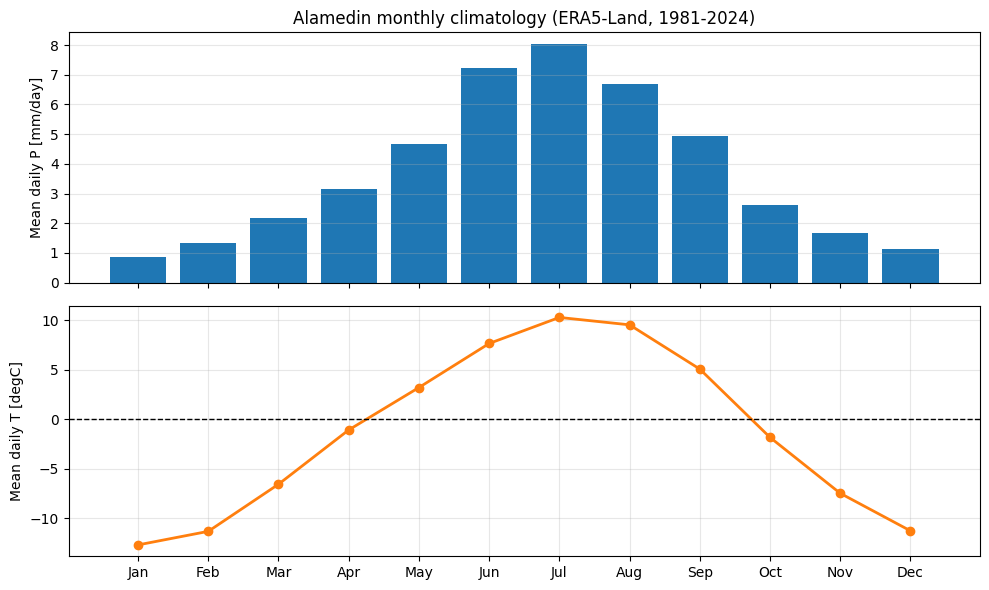

In [16]:
month_numbers = np.arange(1, 13)  # This will create an array: [1, 2, 3, ..., 12]
month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].bar(month_numbers, monthly_precip_mm.values, color="tab:blue")
axes[0].set_ylabel("Mean daily P [mm/day]")
axes[0].set_title("Alamedin monthly climatology (ERA5-Land, 1981-2024)")
axes[0].grid(axis="y", alpha=0.3)

axes[1].plot(month_numbers, monthly_temp_c.values, color="tab:orange", marker="o", linewidth=2.0)
axes[1].axhline(0.0, color="black", linewidth=1.0, linestyle="--")
axes[1].set_ylabel("Mean daily T [degC]")
axes[1].set_xticks(month_numbers)
axes[1].set_xticklabels(month_labels)
axes[1].grid(alpha=0.3)

fig.tight_layout()
fig.savefig(Path("figures") / "alamedin_monthly_climatology.png", dpi=150, bbox_inches="tight")
plt.show()


This is the Alamedin annual cycle.

In the second half of the notebook we will build on these foundations: compute potential evapotranspiration with the `extraterrestrial_radiation` helper, load the streamflow record, measure its gaps with `compute_gap_lengths`, and prepare a clean forcing-plus-discharge dataset.


## 7. Capstone 1: Compute PET with the Oudin Formula
So far we have precipitation and temperature in `forcing_df`.

For a water balance we also need **potential evapotranspiration** (PET): the amount of water a catchment could lose to the atmosphere if it had unlimited moisture.

We will use the Oudin (2005) formula. It needs only three things:

- mean daily temperature $T$ in $^\circ\mathrm{C}$
- day of year $J$ (1 to 365)
- station latitude $\phi$ in radians

That is a good fit for our data, because ERA5-Land already gave us $T$, the date gives us $J$, and the Alamedin gauge latitude is a single known number.

By the end of this section we will have a new column `pet_mm` in `forcing_df` and a plot of the annual PET cycle.


### The Formula

Oudin splits PET into two parts. The second part is a gate: when $T+5$ is not above zero, PET is zero.

$$
\operatorname{PET} =
\begin{cases}
\dfrac{R_a}{\lambda}\,\dfrac{T + 5}{100}
  & \text{if } T + 5 > 0 \\[6pt]
0 & \text{otherwise}
\end{cases}
$$

with $\lambda = 2.45\,\mathrm{MJ\,kg^{-1}}$.

The term $R_a$ is **extraterrestrial radiation**: the solar radiation that would hit a horizontal surface at the top of the atmosphere. It depends on day of year and latitude, not on weather.

We provided `extraterrestrial_radiation(doy, lat_rad)` in the toolbox cell at the top of the notebook. We will call it here.


In [17]:
doy = forcing_df["date"].dt.dayofyear.values
temp_degC = forcing_df["temperature_degC"].values

print(type(doy))
print(doy[:5])
print(temp_degC[:5])


<class 'numpy.ndarray'>
[1 2 3 4 5]
[ -8.3541  -8.6758  -8.9181 -10.1155 -11.422 ]


`.values` takes a pandas column and returns a plain NumPy array. Many numerical functions expect arrays rather than pandas columns, so this conversion is a common pattern.

From here on, `doy` and `temp_degC` are numpy arrays. That means we can hand them to `extraterrestrial_radiation` directly.


In [18]:
lat_rad = np.radians(ALAMEDIN_GAUGE_LAT_DEG)
ra_MJ_m2_day = extraterrestrial_radiation(doy, lat_rad=lat_rad)

print(ra_MJ_m2_day.shape)
print(ra_MJ_m2_day[:5])


(16071,)
[12.10883626 12.16041445 12.21650397 12.2770972  12.34218561]


`ra_MJ_m2_day` has the same length as `forcing_df`. Each value is the top-of-atmosphere solar energy for that day of year at the Alamedin latitude, in $\mathrm{MJ\,m^{-2}\,day^{-1}}$.

It is highest in summer and lowest in winter, even though our computation had nothing to do with cloud cover. That is the point: $R_a$ is the *potential* input, before any atmosphere.


### The Piecewise Part

Look at the formula again. It has two branches:

- if $T + 5 > 0$, compute $\frac{R_a}{\lambda}\,\frac{T + 5}{100}$
- otherwise, return $0$

NumPy has a direct way to express a piecewise choice over a whole array: `np.where(condition, value_if_true, value_if_false)`.

We will build it step by step in the next cell. The condition and the "otherwise" branch are given. The "if true" branch is the piece worth reading carefully — it is the formula translated directly into array arithmetic.


In [19]:
LAMBDA_MJ_per_kg = 2.45  # latent heat of vaporisation

pet_mm = np.where(
    temp_degC + 5.0 > 0.0,
    ra_MJ_m2_day / LAMBDA_MJ_per_kg * (temp_degC + 5.0) / 100.0,  # <-- the "if true" branch
    0.0,
)

print(pet_mm.shape)
print(pet_mm[:5])
print("min:", pet_mm.min(), "max:", pet_mm.max())


(16071,)
[0. 0. 0. 0. 0.]
min: 0.0 max: 3.8337400178847982


`pet_mm` is now a NumPy array with one PET estimate per day.

Days where $T + 5 \leq 0$ — so $T \leq -5^\circ\mathrm{C}$ — are set to zero. On those cold days, Oudin (2005) assumes the atmosphere has no appreciable evaporative demand.

On warmer days, PET grows with both temperature and $R_a$, so summer values are much larger than winter values.


In [20]:
forcing_df["pet_mm"] = pet_mm

print(forcing_df.head())


        date  precipitation_mm  temperature_degC  year  month  day_of_year  \
0 1981-01-01            0.3963           -8.3541  1981      1            1   
1 1981-01-02            0.2877           -8.6758  1981      1            2   
2 1981-01-03            0.2567           -8.9181  1981      1            3   
3 1981-01-04            0.8757          -10.1155  1981      1            4   
4 1981-01-05            1.2102          -11.4220  1981      1            5   

   pet_mm  
0     0.0  
1     0.0  
2     0.0  
3     0.0  
4     0.0  


### Saving The Forcing For Later Notebooks

We save the daily forcing — date, precipitation, mean temperature, Oudin PET — to disk now. Notebook 08 will load this single CSV instead of re-reading the two ERA5 files and recomputing PET. One cleaning step lives in one place; downstream code just reads it back.

In [ ]:
output_folder = ALAMEDIN_FOLDER / "03_processed"
output_folder.mkdir(parents=True, exist_ok=True)
output_path = output_folder / "alamedin_forcing_daily.csv"

forcing_df[["date", "precipitation_mm", "temperature_degC", "pet_mm"]].to_csv(output_path, index=False)

print(f"Saved: {output_path}")

### Annual Cycle of PET

A daily plot of PET across 40+ years would be noisy. A cleaner view is the **mean PET for each calendar month**, averaged over all years.

This is the same `groupby` pattern you saw in section 6. We group by month and take the mean.


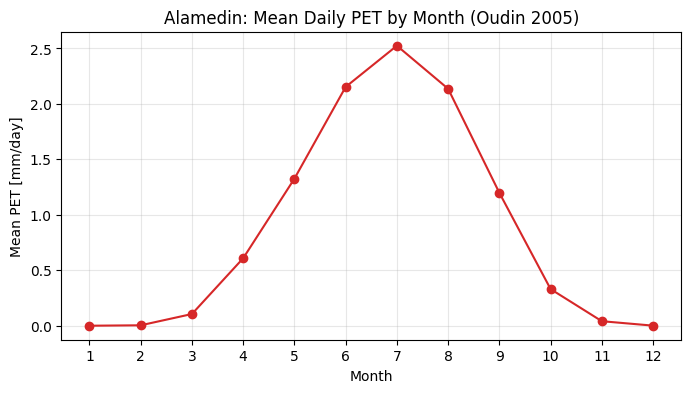

In [21]:
monthly_pet_mm = forcing_df.groupby("month")["pet_mm"].mean()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(monthly_pet_mm.index, monthly_pet_mm.values, marker="o", color="tab:red")
ax.set_xlabel("Month")
ax.set_ylabel("Mean PET [mm/day]")
ax.set_title("Alamedin: Mean Daily PET by Month (Oudin 2005)")
ax.set_xticks(range(1, 13))
ax.grid(alpha=0.3)
plt.show()


The curve peaks around June and July, which is what we expect for a northern mid-latitude catchment. Winter values are close to zero because both $R_a$ and $T$ are low.

We now have a daily PET estimate for Alamedin. Combined with `precipitation_mm` and `temperature_degC`, `forcing_df` contains everything the hydrological model will need on the forcing side.

Next we bring in the missing piece: **measured discharge at the gauge**.


## 8. Read the Alamedin Discharge Record
So far our daily data has come from CSV files. The Alamedin gauge record is stored in an Excel workbook instead. `pandas` has a matching `pd.read_excel(...)` function.

The workbook covers **2000-01-01 to 2019-12-31**. It has five columns: `year`, `month`, `day`, `date`, and `discharge_m3_per_sec`.

We want a clean daily DataFrame with two columns only: `date` and `q_m3s`.


In [22]:
streamflow_path = ALAMEDIN_FOLDER / "01_gauge_data" / "discharge_data_long_alamedin.xlsx"
q_raw_df = pd.read_excel(streamflow_path)

print(q_raw_df.shape)
print(q_raw_df.columns.tolist())
print(q_raw_df.head())


(7305, 5)


['year', 'month', 'day', 'date', 'discharge_m3_per_sec']
   year  month  day       date  discharge_m3_per_sec
0  2000      1    1 2000-01-01                  2.48
1  2000      1    2 2000-01-02                  2.44
2  2000      1    3 2000-01-03                  2.41
3  2000      1    4 2000-01-04                  2.37
4  2000      1    5 2000-01-05                  2.33


The workbook has `year`, `month`, `day` as separate integer columns. There is also a `date` column, but in general you cannot trust that a `date`-looking column was parsed as a real date type. A safer habit is to build the date explicitly from the integer parts.

`pd.to_datetime(...)` accepts a dict with keys `year`, `month`, `day` and returns a proper datetime column.


In [23]:
# We can build a dataframe from a dictionary of columns. The "date" column is built from the year, month and day columns of the raw dataframe.
q_df = pd.DataFrame(
    {
        "date": pd.to_datetime(
            {
                "year": q_raw_df["year"].astype(int),
                "month": q_raw_df["month"].astype(int),
                "day": q_raw_df["day"].astype(int),
            }
        ),
        "q_m3s": q_raw_df["discharge_m3_per_sec"],
    }
)

q_df = q_df.sort_values("date").drop_duplicates("date").reset_index(drop=True)

print(q_df.head())
print(q_df.tail())
print("rows:", len(q_df))


        date  q_m3s
0 2000-01-01   2.48
1 2000-01-02   2.44
2 2000-01-03   2.41
3 2000-01-04   2.37
4 2000-01-05   2.33
           date  q_m3s
7300 2019-12-27   2.26
7301 2019-12-28   2.10
7302 2019-12-29   2.10
7303 2019-12-30   2.10
7304 2019-12-31   2.10
rows: 7305


### Convert Discharge to mm/day

The gauge reports discharge in cubic meters per second ($\mathrm{m^3\,s^{-1}}$). For comparison with precipitation and for model calibration, it is more convenient to express discharge as a depth over the catchment in **millimeters per day**:

$$
Q_{\mathrm{mm/day}} = Q_{\mathrm{m^3/s}} \times \frac{86.4}{A_{\mathrm{km^2}}}
$$

The factor $86.4$ comes from a unit combination involving seconds per day, square meters per square kilometer, and millimeters per meter. Try to derive it yourself.

For Alamedin, `ALAMEDIN_AREA_KM2 = 414.05`.


In [24]:
# This is very similar to the arithmetic operation we did with the NumPy array, but now it's done on a pandas Series. The result is stored in a new column "q_mm" in the DataFrame.
q_df["q_mm"] = q_df["q_m3s"] * 86.4 / ALAMEDIN_AREA_KM2

print(q_df.head())
print(q_df["q_mm"].describe())


        date  q_m3s      q_mm
0 2000-01-01   2.48  0.517503
1 2000-01-02   2.44  0.509156
2 2000-01-03   2.41  0.502896
3 2000-01-04   2.37  0.494549
4 2000-01-05   2.33  0.486202
count    6209.000000
mean        1.451000
std         1.374354
min         0.260838
25%         0.450728
50%         0.730347
75%         2.253641
max         7.303466
Name: q_mm, dtype: float64


`q_df` now has three columns: `date`, `q_m3s`, and `q_mm`. The record runs from 2000-01-01 to 2019-12-31.

Before we merge it into the forcing table, we need to understand where the record is missing and how long the gaps are.


## 9. Where Is the Discharge Record Missing?
Real gauge records have gaps. A sensor fails, a gauge freezes, a technician takes a summer off. Before we decide what to do about a gap, we need to know:

1. how many days are missing
2. whether the missing days come in short bursts or long blocks

We will answer both questions for Alamedin.


In [25]:
print(q_df.isna().sum())


date        0
q_m3s    1096
q_mm     1096
dtype: int64


In [26]:
total_days = len(q_df)
missing_days = int(q_df["q_m3s"].isna().sum())
missing_percent = 100.0 * missing_days / total_days

print(f"{missing_days} missing days out of {total_days} ({missing_percent:.1f}%)")


1096 missing days out of 7305 (15.0%)


### Are All Calendar Days Present?

`isna().sum()` only counts missing values for rows that already exist. If the gauge file simply *skipped* some days, those days would not show up as NaN; they would be absent entirely.

A safer approach is to build a complete daily calendar from the first date to the last date, then reindex the DataFrame onto that calendar. Any day that was absent from the file will appear as a row of NaN.

We will do this in four small steps:

1. build a full daily date range
2. make `date` the DataFrame index
3. reindex onto the full date range
4. move `date` back from the index to a regular column


In [27]:
# 1. Build the complete daily calendar.
full_dates = pd.date_range(q_df["date"].min(), q_df["date"].max(), freq="D")

# 2. Put `date` on the index so reindex knows what to align against.
q_df = q_df.set_index("date")

# 3. Reindex onto the full calendar. Missing calendar days become rows of NaN.
q_df = q_df.reindex(full_dates)

# 4. Move the index back to a regular column and rename it.
q_df = q_df.rename_axis("date").reset_index()

print(len(q_df))
print(q_df.isna().sum())


7305
date        0
q_m3s    1096
q_mm     1096
dtype: int64


The row count did not change. That means every calendar day between 2000-01-01 and 2019-12-31 was already present in the workbook. The 1096 missing days were recorded as NaN inside the file, not as absent rows.

That is good news. On other datasets, this same four-step pattern would have exposed silent calendar gaps, and you would always want to run it before any time-based analysis.


### How Long Are the Gaps?

Counting missing days is not enough. One NaN surrounded by observations is very different from a NaN inside a three-year block.

We provided `compute_gap_lengths(series)` in the toolbox at the top of the notebook. It takes a pandas Series and returns an integer Series of the same length, where:

- an observed day gets `0`
- a missing day gets the total length of the gap it belongs to

So a day inside a one-day gap gets `1`. A day inside a 100-day gap gets `100`.


In [61]:
q_df["gap_length_days"] = compute_gap_lengths(q_df["q_m3s"])

print(q_df.head())
print("Unique gap-length values (nonzero):")
print(sorted(q_df.loc[q_df["gap_length_days"] > 0, "gap_length_days"].unique()))


        date  q_m3s      q_mm  gap_length_days  q_m3s_clean  q_status  \
0 2000-01-01   2.48  0.517503                0         2.48  observed   
1 2000-01-02   2.44  0.509156                0         2.44  observed   
2 2000-01-03   2.41  0.502896                0         2.41  observed   
3 2000-01-04   2.37  0.494549                0         2.37  observed   
4 2000-01-05   2.33  0.486202                0         2.33  observed   

   q_mm_clean  
0    0.517503  
1    0.509156  
2    0.502896  
3    0.494549  
4    0.486202  
Unique gap-length values (nonzero):
[np.int64(1096)]


There is only one missing value appearing in `unique`: **1096**. Every single missing day in the Alamedin record belongs to the same block, and that block is 1096 days long — three full years.

This is a very specific kind of missing-data problem. We cannot repair it with small local interpolation. We will come back to this in the next section.

First, let us see the gap visually.


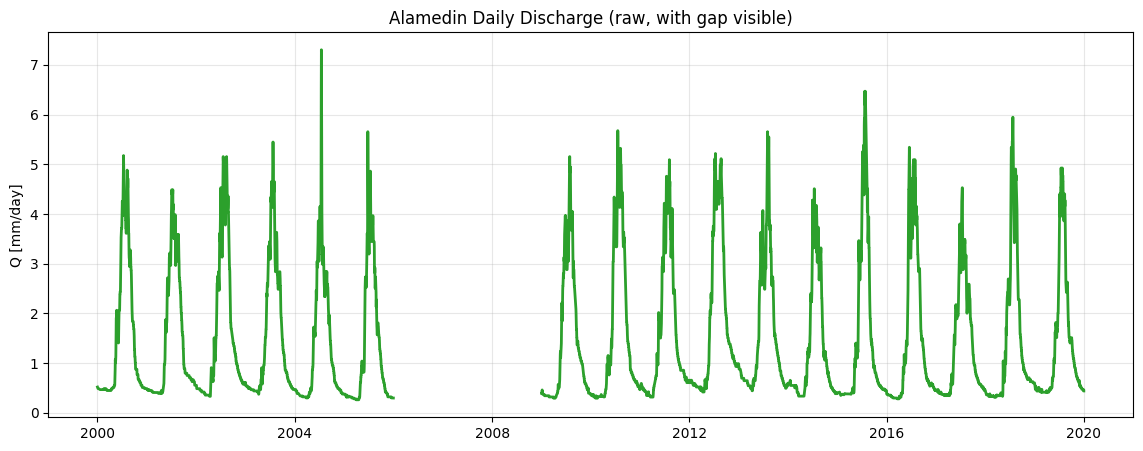

In [29]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(q_df["date"], q_df["q_mm"], color="tab:green", linewidth=2)
ax.set_ylabel("Q [mm/day]")
ax.set_title("Alamedin Daily Discharge (raw, with gap visible)")
ax.grid(alpha=0.3)
plt.show()


## 10. Capstone 2: Clean the Alamedin Record

Alamedin's streamflow record has exactly one missing block: 1096 days, from 2006 to 2008. That block is far too long for any interpolation method to fill honestly — a straight line across three years of a mountain river would be meaningless.

So what does "cleaning" mean for a record like this?

Two things:

1. **Mark provenance.** Every day in the final DataFrame should say where its value came from — an observation, a filled interpolation, or still missing.
2. **Learn the technique for future datasets.** Most gauge records you will encounter in your career have a mix of gap sizes: one-day sensor dropouts, week-long freezes, occasional month-long blanks. The technique we build here — interpolate only short internal gaps, leave long gaps missing — is the standard first pass on any daily gauge record.

We will proceed in five steps:

1. Learn what `.interpolate` does, on a tiny synthetic Series
2. State the short-gap rule
3. Apply the rule to Alamedin (it will fill zero days — correctly)
4. Add a `q_status` column for provenance
5. Save the cleaned DataFrame

### Linear Interpolation

`pandas` has an `.interpolate(...)` method that estimates missing values from neighboring observed values. With `method="linear"`, it draws a straight line between the observed values on either side of a NaN and fills the NaN with points on that line.

The argument `limit_area="inside"` tells `pandas` not to interpolate past the first or last observed value. It would not make sense to draw a line from nothing.

Alamedin's only gap is too long to learn from: we cannot see interpolation work on a 1096-day block without producing nonsense. So let's see the method on a synthetic Series first, where the gap is short enough that the straight-line fill is obviously sensible.

In [59]:
toy_series = pd.Series([1.0, 2.0, np.nan, np.nan, 5.0, 6.0])
print("Original:")
print(toy_series)

Original:
0    1.0
1    2.0
2    NaN
3    NaN
4    5.0
5    6.0
dtype: float64


In [60]:
print("After linear interpolation:")
print(toy_series.interpolate(method="linear"))

After linear interpolation:
0    1.0
1    2.0
2    3.0
3    4.0
4    5.0
5    6.0
dtype: float64


The two `NaN` values were replaced by `3.0` and `4.0`: the straight line connecting `2.0` and `5.0` passes through those values at the right positions. That is all linear interpolation is — a straight line between the two known endpoints of a gap.

### The Short-Gap Rule

On a daily gauge record, the standard first-pass cleaning rule is:

- if a missing day belongs to a gap of **1 to 5 days**, interpolate linearly from the neighbors
- if it belongs to a longer gap, leave it missing

Five days is a reasonable limit for daily streamflow on a mountain river. Across five days, streamflow can change a lot, but a straight line between observed endpoints is usually not far wrong. Across months or years, a straight line is obviously meaningless.

We set the limit as a named constant so it is easy to change for other basins.

In [31]:
SHORT_GAP_LIMIT_DAYS = 5

print(f"Interpolating gaps of 1 to {SHORT_GAP_LIMIT_DAYS} days; leaving longer gaps missing.")

Interpolating gaps of 1 to 5 days; leaving longer gaps missing.


### Applying the Rule to Alamedin

Alamedin has one gap, and it is 1096 days long. The rule above will therefore fill **zero days** on this record — as it should. We still walk through the code, for two reasons:

- on Ala-Archa or any basin with mixed gap sizes, exactly this code would fill real short gaps
- Alamedin still needs a `q_m3s_clean` column and a `q_status` column, even if the cleaning rule does not modify any values

The next cell runs `.interpolate` on the full series. Note that at this stage we compute interpolated values for **every** NaN, regardless of its gap length. The mask in the step after that is what keeps the long-gap interpolations out of the final column.

In [32]:
interpolated_q_m3s = q_df["q_m3s"].interpolate(method="linear", limit_area="inside")

print("NaN count before interpolation:", int(q_df["q_m3s"].isna().sum()))
print("NaN count after interpolation:", int(interpolated_q_m3s.isna().sum()))

NaN count before interpolation: 1096
NaN count after interpolation: 0


### Keep Only the Short-Gap Interpolations

Look at the count: every NaN got a linear estimate, including the 3-year block. A straight line across 1096 days is not something we want to keep.

To filter, we build a boolean mask that is `True` only for days inside gaps of 1 to 5 days. We copy the original `q_m3s` column, and only at positions where the mask is `True`, we overwrite with the interpolated value.

In [33]:
short_gap_mask = q_df["gap_length_days"].between(1, SHORT_GAP_LIMIT_DAYS)

q_df["q_m3s_clean"] = q_df["q_m3s"]
q_df.loc[short_gap_mask, "q_m3s_clean"] = interpolated_q_m3s.loc[short_gap_mask]

print("short-gap rows:", int(short_gap_mask.sum()))
print("remaining missing after cleaning:", int(q_df["q_m3s_clean"].isna().sum()))

short-gap rows: 0
remaining missing after cleaning: 1096


Zero short-gap days. That is the correct outcome for Alamedin: every missing day belongs to the single 1096-day block, so the mask kept all of the interpolated values out of `q_m3s_clean`, and the final column still has 1096 NaN where the gauge was silent.

If we were running the same workflow on Ala-Archa, the mask would catch a handful of short gaps and the number of filled days would be nonzero.

### Track Provenance with `q_status`

A cleaned dataset is much more useful when it tells you *where each value came from*. We add a `q_status` column with three possible values:

- `"observed"` — the original gauge measurement was kept
- `"interpolated_1to5d_gap"` — the value was filled by short-gap interpolation
- `"missing_long_gap"` — the value is still NaN

Downstream, anyone using this table can filter on `q_status` to know which days are real observations.


In [34]:
q_df["q_status"] = "observed"
q_df.loc[short_gap_mask, "q_status"] = "interpolated_1to5d_gap"
q_df.loc[q_df["q_m3s_clean"].isna(), "q_status"] = "missing_long_gap"

print(q_df["q_status"].value_counts())


q_status
observed            6209
missing_long_gap    1096
Name: count, dtype: int64


### Recompute `q_mm` on the Clean Column

We also recompute `q_mm` from the cleaned m³/s column, so downstream work uses the cleaned values consistently.


In [35]:
q_df["q_mm_clean"] = q_df["q_m3s_clean"] * 86.4 / ALAMEDIN_AREA_KM2

print(q_df[["date", "q_m3s_clean", "q_mm_clean", "q_status"]].head())


        date  q_m3s_clean  q_mm_clean  q_status
0 2000-01-01         2.48    0.517503  observed
1 2000-01-02         2.44    0.509156  observed
2 2000-01-03         2.41    0.502896  observed
3 2000-01-04         2.37    0.494549  observed
4 2000-01-05         2.33    0.486202  observed


### Before and After

The most honest way to check cleaning work is to plot the original series and the cleaned series together. For Alamedin, the two lines should be identical everywhere — because no interpolation happened.

For a basin with short gaps, you would see small filled segments on the cleaned line that are absent on the raw line.


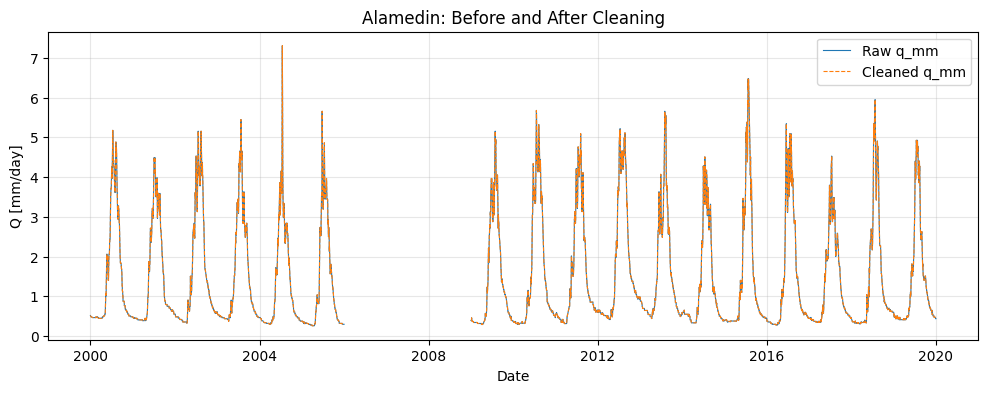

In [36]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(q_df["date"], q_df["q_mm"], color="tab:blue", linewidth=0.8, label="Raw q_mm")
ax.plot(q_df["date"], q_df["q_mm_clean"], color="tab:orange", linewidth=0.8, linestyle="--", label="Cleaned q_mm")
ax.set_xlabel("Date")
ax.set_ylabel("Q [mm/day]")
ax.set_title("Alamedin: Before and After Cleaning")
ax.legend()
ax.grid(alpha=0.3)
plt.show()


### Save the Cleaned Dataset

Finally, we save the cleaned DataFrame as a CSV. Saving intermediate results is a habit worth building. Later notebooks — the modelling notebook, the calibration notebook — will read this file directly instead of repeating this whole cleaning pipeline.


In [37]:
output_folder = ALAMEDIN_FOLDER / "03_processed"
output_folder.mkdir(parents=True, exist_ok=True)
output_path = output_folder / "alamedin_cleaned_daily.csv"

q_df.to_csv(output_path, index=False)

observed_days = int((q_df["q_status"] == "observed").sum())
filled_days = int((q_df["q_status"] == "interpolated_1to5d_gap").sum())
missing_days_final = int((q_df["q_status"] == "missing_long_gap").sum())

print(f"Saved: {output_path}")
print(f"{observed_days} days observed, {filled_days} days filled, {missing_days_final} days still missing")


Saved: /Users/nicolaslazaro/Desktop/2025_02_TW_ETHZ_CA_IWRM/02_data/15189_Alamedin_River_KGZ/03_processed/alamedin_cleaned_daily.csv
6209 days observed, 0 days filled, 1096 days still missing


Alamedin is now cleaned and on disk with provenance information. Any downstream code can reconstruct which days are real observations, which were filled, and which are still missing.

For calibration, you would typically restrict the training period to a block where `q_status == "observed"` is dense. For Alamedin, the obvious choice is either 2000–2005 or 2009–2019.


## Wrap-Up

You can now:

- create and do arithmetic with NumPy arrays
- rewrite a loop over values as one line of `np.where`
- read a CSV file into a pandas DataFrame
- inspect a DataFrame with `.head()`, `.shape`, and `.describe()`
- select one column as a Series
- make a simple line plot with `matplotlib`
- make a multi-panel figure with shared x-axis
- save a figure to disk
- merge two DataFrames on a common column
- use the `.dt` accessor to pull date parts out of a date column
- use `.groupby(...)` to compute monthly means
- read an Excel workbook with `pd.read_excel`
- build a date column from integer year/month/day pieces
- detect and measure gaps in a daily record
- interpolate only short internal gaps of up to 5 days
- track provenance with a `q_status` column
- save a cleaned dataset for later model calibration

Next, you can build on these cleaned basin tables in the modelling notebook.
